<p>
    <a href="https://umt.edu.al/en/anxhelo-shehu/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2022/10/Anxhelo-Shehu-min-2-300x300.jpg" width="150" alt="UMT Logo">
    </a>
</p>
<p>
    <a href="https://umt.edu.al/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2024/11/Universiteti-Metropolitan-Tirana.webp" width="200" alt="UMT Logo">
    </a>
</p>

## 50% e materialit të mëposhtëm është marrë nga:
https://www.tensorflow.org/tutorials/images/cnn
##### Copyright 2019 The TensorFlow Authors.

In [1]:
#@title Licencuar nën Licencën Apache, Versioni 2.0 (në vijim "Licenca");
# Nuk lejohet përdorimi i këtij skedari përveçse në përputhje me Licencën.
# Mund të merrni një kopje të Licencës në:
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Përveçse kur kërkohet nga ligji ose është rënë dakord me shkrim, softueri
# i shpërndarë nën këtë Licencë shpërndahet "SIÇ ËSHTË",
# PA ASNJË LLOJ GARANCIE APO KUSHTI, të shprehur apo të nënkuptuar.
# Shihni Licencën për lejet dhe kufizimet specifike në bazë të saj.


# Convolutional Neural Network (CNN)

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/images/cnn">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/images/cnn.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/images/cnn.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/images/cnn.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

Kjo udhëzues demonstron trajnimin e një [Rrjeti Neural Konvolucional](https://developers.google.com/machine-learning/glossary/#convolutional_neural_network) (CNN) të thjeshtë për të klasifikuar imazhet nga [CIFAR](https://www.cs.toronto.edu/~kriz/cifar.html).  

Për shkak se ky udhëzues përdor [Keras Sequential API](https://www.tensorflow.org/guide/keras/overview), krijimi dhe trajnimi i modelit tënd do të kërkojë vetëm disa rreshta kodi.

### Import TensorFlow

In [5]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

### Shkarko dhe përgatit dataset-in CIFAR10

Dataset-i **CIFAR10** përmban **60,000 imazhe me ngjyra** të ndara në **10 klasa**, me nga **6,000 imazhe për çdo klasë**. Ky dataset ndahet në **50,000 imazhe për trajnimin** e modelit dhe **10,000 imazhe për testim**.  

Klasat janë **reciprokisht ekskluzive**, që do të thotë se nuk ka mbivendosje midis tyre.

In [6]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

### Verify the data

To verify that the dataset looks correct, let's plot the first 25 images from the training set and display the class name below each image:


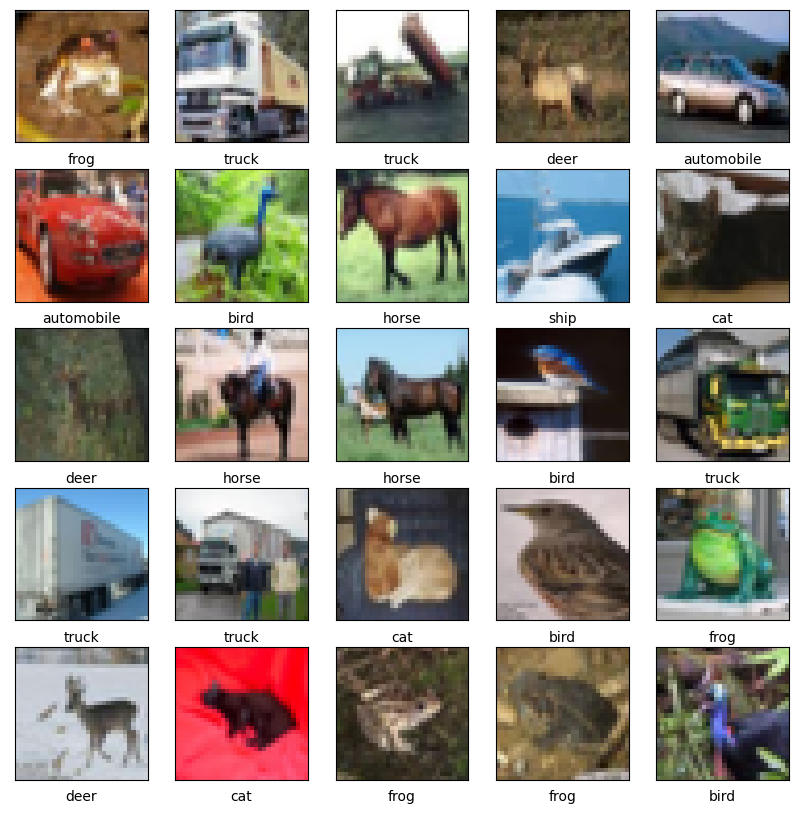

In [7]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

### Kuptimi i Layerave ne model (Blloqeve Konvolucionare dhe bashkimit pergjat shtresave)

In [8]:
import cv2

# Lexo imazhin nga rruga e dhënë
img = cv2.imread('imazhi.jpg')

In [9]:
img.shape

(1273, 1004, 3)

In [10]:
model = models.Sequential()
model.add(layers.Conv2D(8, (3, 3), activation='relu', input_shape=(1273, 1004, 3)))
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 1271, 1002, 8)     224       
                                                                 
Total params: 224 (896.00 Byte)
Trainable params: 224 (896.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
# Merr filtrat dhe bias nga shtresa e parë Conv2D
filters, biases = model.layers[0].get_weights()

print(f'Forma e filtrave: {filters.shape}') 

Forma e filtrave: (3, 3, 3, 8)


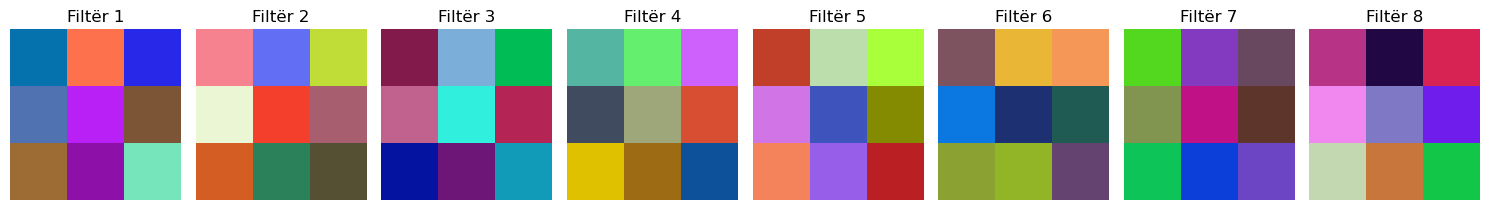

In [12]:
# Normalizo filtrat për vizualizim
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Vizualizo secilin filtër
n_filters = filters.shape[3]

plt.figure(figsize=(15, 5))

for i in range(n_filters):
    # Merr filtrin e i-të (3x3x3)
    f = filters[:, :, :, i]
    
    # Vizato si imazh
    plt.subplot(1, n_filters, i + 1)
    plt.imshow(f)
    plt.axis('off')
    plt.title(f'Filtër {i+1}')

plt.tight_layout()
plt.show()


In [13]:
f

array([[[0.71867615, 0.20327711, 0.5251649 ],
        [0.13589716, 0.03036342, 0.2731194 ],
        [0.84233934, 0.13821284, 0.32811457]],

       [[0.9461826 , 0.53484476, 0.94464433],
        [0.50160486, 0.47293267, 0.77444416],
        [0.431757  , 0.11423826, 0.92739046]],

       [[0.76748365, 0.8447621 , 0.6933229 ],
        [0.7852808 , 0.46370623, 0.23590937],
        [0.07090864, 0.7772507 , 0.28179392]]], dtype=float32)

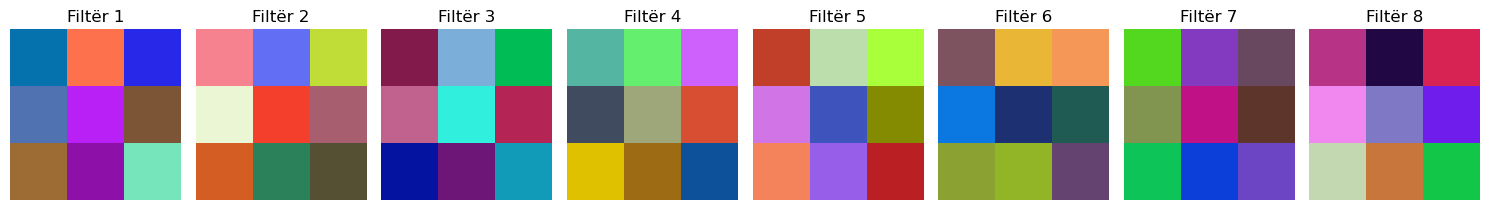

In [14]:
# Vizualizo secilin filtër
n_filters = 8

plt.figure(figsize=(15, 5))

for i in range(n_filters):
    # Merr filtrin e i-të (3x3x3)
    f = filters[:, :, :, i]
    
    # Vizato si imazh
    plt.subplot(1, n_filters, i + 1)
    plt.imshow(f)
    plt.axis('off')
    plt.title(f'Filtër {i+1}')

plt.tight_layout()
plt.show()


In [17]:
# tani aplikojme keta filtra mbi imazhin:

In [18]:
import numpy as np
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Konverto në RGB
img_input = np.expand_dims(img, axis=0)  # Shto batch dimension


1/1 [==============================] - 0s 215ms/step


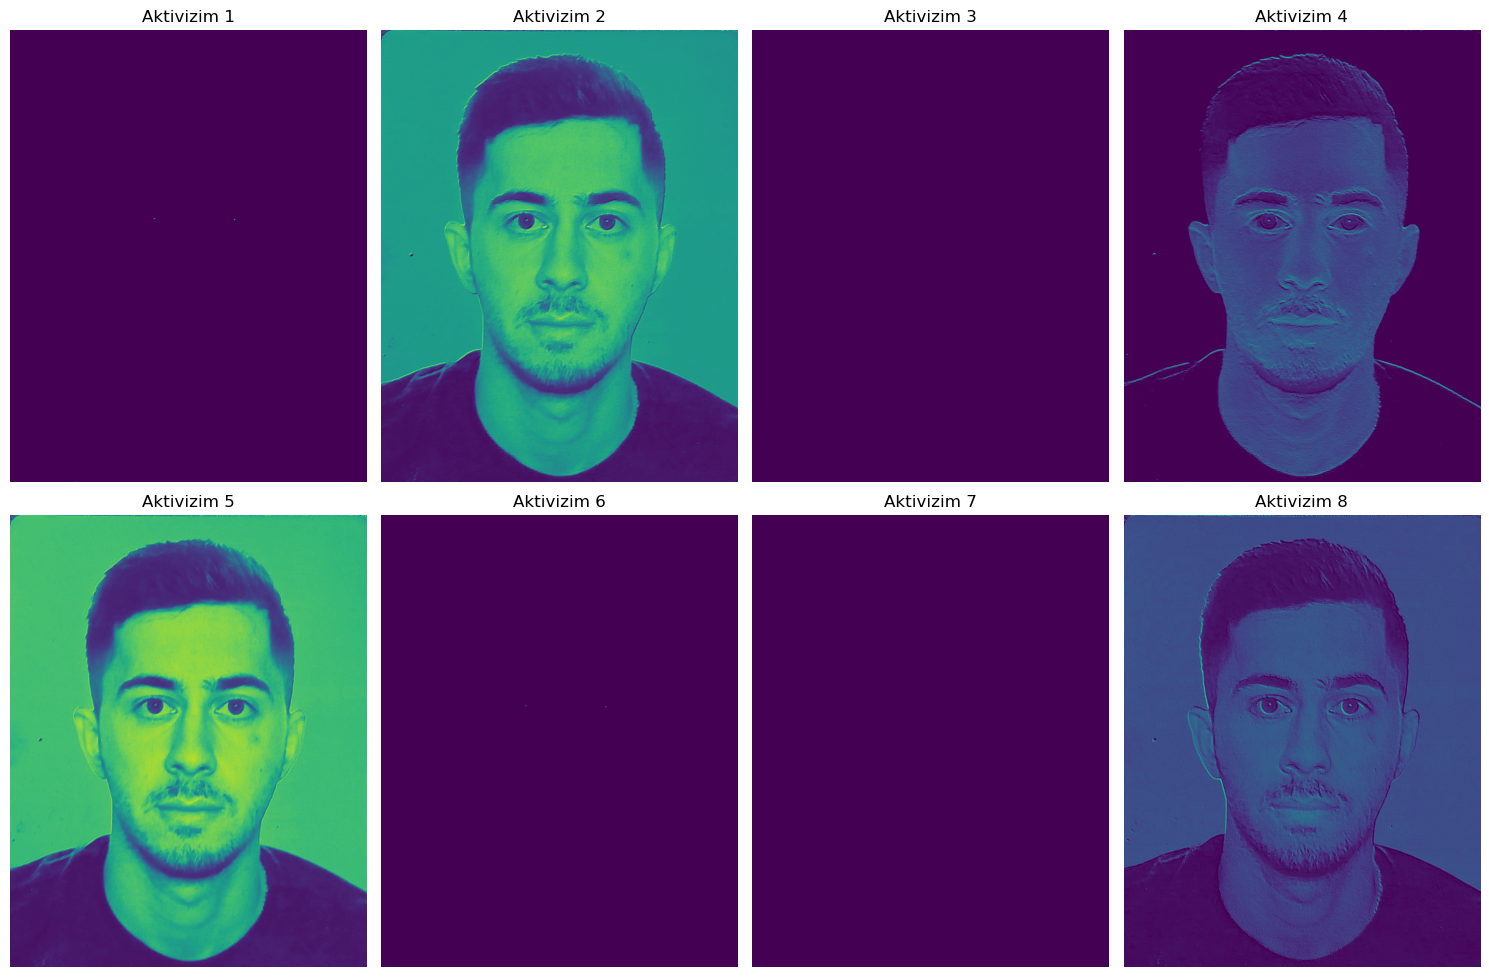

In [19]:
# 3. Krijo një model që kthen daljen e shtresës së parë
activation_model = models.Model(inputs=model.input, outputs=model.layers[0].output)

# 4. Merr aktivizimet
activations = activation_model.predict(img_input)

# 5. Vizualizo aktivizimet (1 imazh për çdo filtër)
n_filters = activations.shape[-1]

plt.figure(figsize=(15, 10))
for i in range(n_filters):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(activations[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Aktivizim {i+1}')
plt.tight_layout()
plt.show()

In [20]:
model.add(layers.MaxPooling2D((4, 4)))


In [21]:
# Krijo model për aktivizimet pas Conv2D dhe pas MaxPooling2D
activation_model = models.Model(inputs=model.input, outputs=[model.layers[0].output, model.layers[1].output])
conv_activations, pool_activations = activation_model.predict(img_input)

# Printo dimensionet
print("Forma pas Conv2D:", conv_activations.shape)     
print("Forma pas MaxPooling2D:", pool_activations.shape) 


1/1 [==============================] - 0s 103ms/step
Forma pas Conv2D: (1, 1271, 1002, 8)
Forma pas MaxPooling2D: (1, 317, 250, 8)


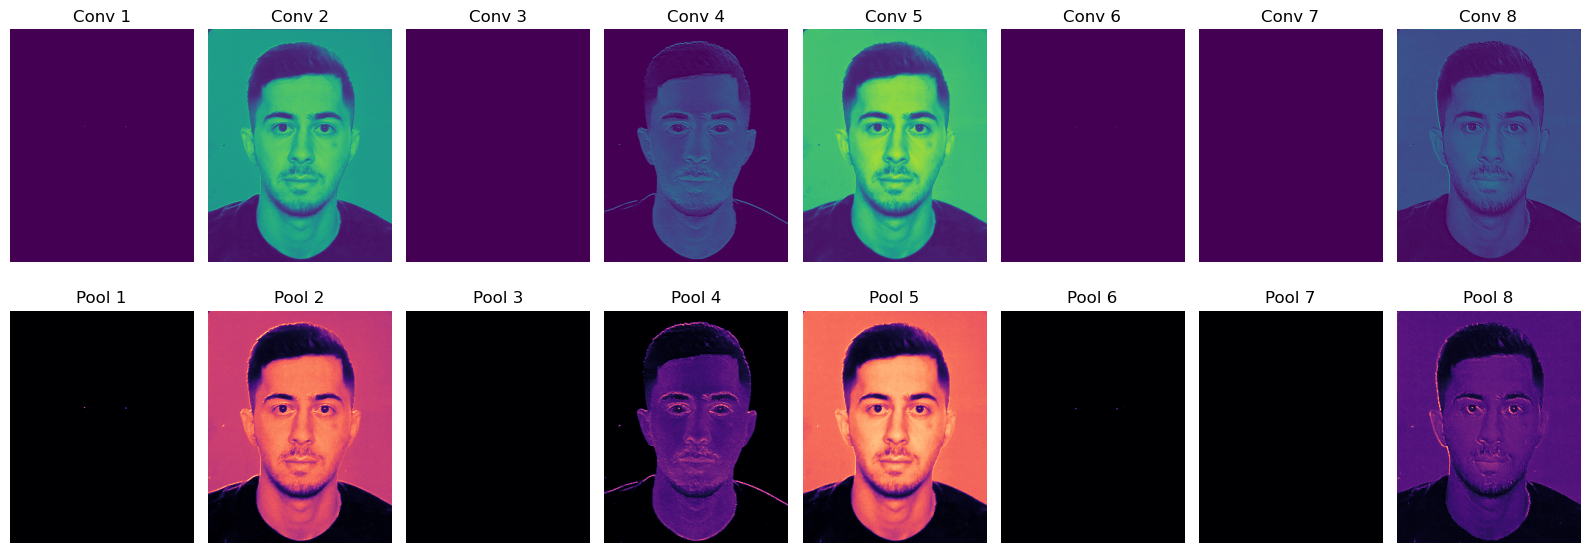

In [26]:

#  Vizualizo aktivizimet pas Conv2D
plt.figure(figsize=(16, 6))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(conv_activations[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Conv {i+1}')

# Vizualizo aktivizimet pas MaxPooling2D
for i in range(8):
    plt.subplot(2, 8, i + 9)
    plt.imshow(pool_activations[0, :, :, i], cmap='magma')
    plt.axis('off')
    plt.title(f'Pool {i+1}')

plt.tight_layout()
plt.show()

In [27]:
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((4, 4)))


In [28]:
# Krijo model për aktivizimet pas shtresës së dytë Conv2D dhe MaxPooling2D
activation_model = models.Model(inputs=model.input, outputs=[model.layers[2].output, model.layers[3].output])
conv_activations, pool_activations = activation_model.predict(img_input)

# Printo dimensionet pas ketyre shtresave
print("Forma pas Conv2D (64 filtra):", conv_activations.shape)     
print("Forma pas MaxPooling2D (64 filtra):", pool_activations.shape)  

1/1 [==============================] - 0s 128ms/step
Forma pas Conv2D (64 filtra): (1, 315, 248, 64)
Forma pas MaxPooling2D (64 filtra): (1, 78, 62, 64)


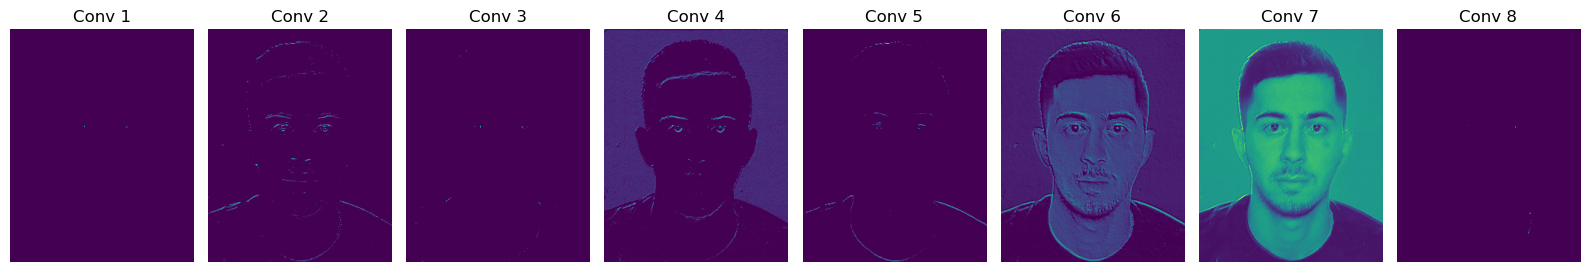

In [29]:

# Vizualizo vetëm 8 aktivizimet e para pas Conv2D (64 filtra)
plt.figure(figsize=(16, 6))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(conv_activations[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Conv {i+1}')

plt.tight_layout()
plt.show()

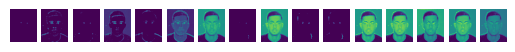

In [30]:
# Vizualizo aktivizimet pas MaxPooling2D
for i in range(16):
    plt.subplot(1, 16, i + 1)
    plt.imshow(pool_activations[0, :, :, i])
    plt.axis('off')

In [31]:
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((3, 3)))

In [32]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 1271, 1002, 8)     224       
                                                                 
 max_pooling2d (MaxPooling2  (None, 317, 250, 8)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 315, 248, 64)      4672      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 78, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 76, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 25, 20, 128)       0

In [33]:
# Krijo model për aktivizimet pas shtresës së dytë Conv2D dhe MaxPooling2D
activation_model = models.Model(inputs=model.input, outputs=[model.layers[4].output, model.layers[5].output])
conv_activations, pool_activations = activation_model.predict(img_input)

# Printo dimensionet pas ketyre shtresave
print("Forma pas Conv2D (128 filtra):", conv_activations.shape)     
print("Forma pas MaxPooling2D (128 filtra):", pool_activations.shape)  

1/1 [==============================] - 0s 151ms/step
Forma pas Conv2D (128 filtra): (1, 76, 60, 128)
Forma pas MaxPooling2D (128 filtra): (1, 25, 20, 128)


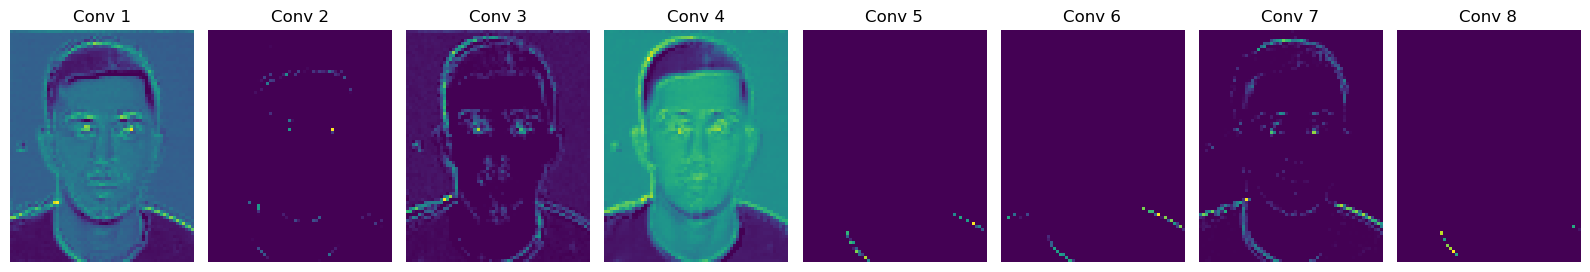

In [38]:

# Vizualizo vetëm 8 aktivizimet e para pas Conv2D (64 filtra)
plt.figure(figsize=(16, 6))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(conv_activations[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Conv {i+1}')

plt.tight_layout()
plt.show()

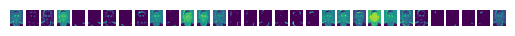

In [37]:
# Vizualizo aktivizimet pas MaxPooling2D
# plt.figure(figsize=(16, 6))
for i in range(32):
    plt.subplot(1, 32, i + 1)
    plt.imshow(pool_activations[0, :, :, i])
    plt.axis('off')
    #plt.title(f'Pool {i+1}')

### Krijo edhe trainojme nje model CNN per detyren e klasifikimit te OB ne datasetin e mesiperm
#### Si fillim krijojme bazen konvolucionale


6 rreshtat e mëposhtëm të kodit përkufizojnë bazën konvolucionale duke ndjekur një model të zakonshëm: një grumbull shtresash [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) dhe [MaxPooling2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D).

Si hyrje, një CNN pranon tensore me formë **(lartësia_e_imazhit, gjërësia_e_imazhit, kanalet_e_ngjyrave)**, duke injoruar madhësinë e grumbullit (batch size). Nëse je i ri me këto dimensione, **kanalet e ngjyrave** i referohen (R, G, B).  

Në këtë shembull, do të konfigurosh rrjetin CNN për të përpunuar hyrje me formën **(32, 32, 3)**, që është formati i imazheve në dataset-in CIFAR. Këtë mund ta bësh duke kaluar argumentin `input_shape` tek shtresa jote e parë.

In [39]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

Let's display the architecture of your model so far:

In [40]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
Total params: 56320 (220.00 KB)
Trainable params: 5632

Më sipër, mund të shihni që dalja e çdo shtrese **Conv2D** dhe **MaxPooling2D** është një tensor 3D me formën *(lartësia, gjërësia, kanalet)*. Dimensionet e gjërësisë dhe lartësisë kanë tendencë të zvogëlohen ndërsa rrjeti shkon më thellë. Numri i kanaleve të daljes për çdo shtresë **Conv2D** kontrollohet nga argumenti i parë (p.sh., 32 ose 64). Zakonisht, ndërsa gjërësia dhe lartësia zvogëlohen, mund të përballoni (në mënyrë llogaritëse) të shtoni më shumë kanale daljeje në çdo shtresë **Conv2D**.

### Shto shtresat Dense në fund

Për të përfunduar modelin, do të ushqeni tensorin e fundit të daljes nga baza konvolucionale (me formë *(4, 4, 64)*) në një ose më shumë shtresa **Dense** për të kryer klasifikimin. Shtresat **Dense** marrin si hyrje vektorë (që janë 1D), ndërsa dalja aktuale është një tensor 3D. Fillimisht, do ta **sheshojmë** (ose rrokullisim) daljen 3D në 1D, dhe më pas do të shtojmë një ose më shumë shtresa **Dense** mbi të. CIFAR ka 10 klasa daljeje, kështu që përdorim një shtresë **Dense** përfundimtare me 10 dalje.

In [41]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

Këtu është arkitektura e plotë e modelit ton:

In [42]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 1024)             

Përmbledhja e rrjetit tregon se daljet me formë *(4, 4, 64)* janë sheshuar në vektorë me formë *(1024)* përpara se të kalonin nëpër dy shtresa **Dense**.

### Kompilojme edhe trainojme modelin

In [43]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))


Epoch 1/10


1563/1563 [==============================] - 43s 26ms/step - loss: 1.5505 - accuracy: 0.4351 - val_loss: 1.3284 - val_accuracy: 0.5219
Epoch 2/10
1563/1563 [==============================] - 42s 27ms/step - loss: 1.1944 - accuracy: 0.5753 - val_loss: 1.0906 - val_accuracy: 0.6156
Epoch 3/10
1563/1563 [==============================] - 41s 26ms/step - loss: 1.0436 - accuracy: 0.6313 - val_loss: 1.0846 - val_accuracy: 0.6195
Epoch 4/10
1563/1563 [==============================] - 38s 24ms/step - loss: 0.9415 - accuracy: 0.6683 - val_loss: 0.9934 - val_accuracy: 0.6520
Epoch 5/10
1563/1563 [==============================] - 38s 24ms/step - loss: 0.8709 - accuracy: 0.6936 - val_loss: 0.9012 - val_accuracy: 0.6874
Epoch 6/10
1563/1563 [==============================] - 37s 23ms/step - loss: 0.8128 - accuracy: 0.7150 - val_loss: 0.9335 - val_accuracy: 0.6785
Epoch 7/10
1563/1563 [==============================] - 38s 24ms/step - loss: 0.7693 - accuracy: 0.7296 - val_loss: 0.915

### Vlerësojm modelin

313/313 - 2s - loss: 0.9069 - accuracy: 0.6900 - 2s/epoch - 7ms/step


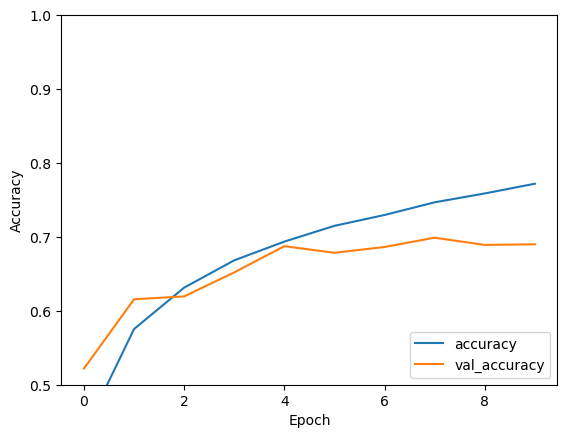

In [44]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [45]:
print(test_acc)

0.6899999976158142
